<a href="https://colab.research.google.com/github/chaudharyaakash1111/-AI-Driven-Disaster-Response-/blob/main/Battery%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import os
import re

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("patrickfleith/nasa-battery-dataset")

print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/nasa-battery-dataset


In [3]:
# Set up matplotlib for inline plotting
%matplotlib inline

In [8]:
# Define paths
data_dir = r"/kaggle/input/nasa-battery-dataset/cleaned_dataset/data"
metadata_path = r"/kaggle/input/nasa-battery-dataset/cleaned_dataset/metadata.csv"


In [10]:
# Load metadata
try:
    metadata = pd.read_csv(metadata_path)
    print("Metadata columns:", metadata.columns)
    print(metadata.head())
except Exception as e:
    raise Exception(f"Error loading metadata.csv: {str(e)}")


Metadata columns: Index(['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id',
       'uid', 'filename', 'Capacity', 'Re', 'Rct'],
      dtype='object')
        type                                         start_time  \
0  discharge  [2010.       7.      21.      15.       0.    ...   
1  impedance  [2010.       7.      21.      16.      53.    ...   
2     charge  [2010.       7.      21.      17.      25.    ...   
3  impedance                    [2010    7   21   20   31    5]   
4  discharge  [2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...   

   ambient_temperature battery_id  test_id  uid   filename  \
0                    4      B0047        0    1  00001.csv   
1                   24      B0047        1    2  00002.csv   
2                    4      B0047        2    3  00003.csv   
3                   24      B0047        3    4  00004.csv   
4                    4      B0047        4    5  00005.csv   

             Capacity                   Re             

In [11]:
# Check available batteries
print("Available batteries:", metadata['battery_id'].unique())

Available batteries: ['B0047' 'B0045' 'B0048' 'B0046' 'B0043' 'B0032' 'B0039' 'B0040' 'B0029'
 'B0028' 'B0042' 'B0034' 'B0038' 'B0033' 'B0030' 'B0041' 'B0027' 'B0044'
 'B0036' 'B0025' 'B0026' 'B0031' 'B0049' 'B0050' 'B0052' 'B0051' 'B0006'
 'B0005' 'B0007' 'B0018' 'B0053' 'B0054' 'B0056' 'B0055']


In [12]:
# Filter metadata for battery B0005 and constant temperature (24 deg C)
battery_id = 'B0005'
temp = 24
metadata_b0005 = metadata[(metadata['battery_id'] == battery_id) & (metadata['ambient_temperature'] == temp)]
if metadata_b0005.empty:
    print(f"No data found for battery {battery_id} at temperature {temp} deg C.")
    raise ValueError(f"Please check metadata or adjust battery_id/temperature.")


In [13]:
# Print cycle counts
print("Impedance cycles:", len(metadata_b0005[metadata_b0005['type'] == 'impedance']))
print("Discharge cycles:", len(metadata_b0005[metadata_b0005['type'] == 'discharge']))


Impedance cycles: 278
Discharge cycles: 168


In [14]:
# Task a: 3D Plot of EIS Measurements using Battery_impedance
eis_data = []
cycle_counts = []


Processed impedance file: 05161.csv for cycle 40
Processed impedance file: 05163.csv for cycle 42
Processed impedance file: 05165.csv for cycle 44
Processed impedance file: 05167.csv for cycle 46
Processed impedance file: 05169.csv for cycle 48
Processed impedance file: 05171.csv for cycle 50
Processed impedance file: 05173.csv for cycle 52
Processed impedance file: 05175.csv for cycle 54
Processed impedance file: 05177.csv for cycle 56
Processed impedance file: 05179.csv for cycle 58
Processed impedance file: 05181.csv for cycle 60
Processed impedance file: 05183.csv for cycle 62
Processed impedance file: 05185.csv for cycle 64
Processed impedance file: 05187.csv for cycle 66
Processed impedance file: 05189.csv for cycle 68
Processed impedance file: 05191.csv for cycle 70
Processed impedance file: 05193.csv for cycle 72
Processed impedance file: 05195.csv for cycle 74
Processed impedance file: 05197.csv for cycle 76
Processed impedance file: 05199.csv for cycle 78
Processed impedance 

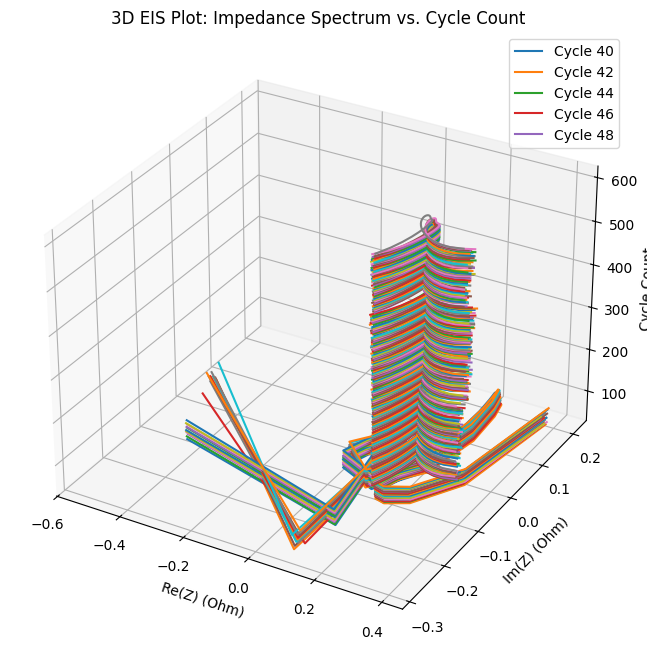

In [15]:
# Function to parse complex impedance string
def parse_complex_impedance(impedance_str):
    try:
        # Remove parentheses and split into real and imaginary parts
        impedance_str = impedance_str.strip('()')
        # Handle cases like "-0.43892624830326377-0.107298295835479j"
        match = re.match(r'([-]?\d+\.\d+)([-+]\d+\.\d+)j', impedance_str)
        if match:
            real_part = float(match.group(1))
            imag_part = float(match.group(2))
            return real_part, imag_part
        else:
            return np.nan, np.nan
    except (ValueError, TypeError, AttributeError):
        return np.nan, np.nan

for idx, row in metadata_b0005.iterrows():
    if row['type'] == 'impedance':
        file_name = row['filename']
        cycle_num = int(row.get('test_id', idx))
        file_path = os.path.join(data_dir, file_name)
        if not os.path.exists(file_path):
            print(f"Warning: File {file_path} not found, skipping.")
            continue
        try:
            df = pd.read_csv(file_path)
            if 'Battery_impedance' not in df.columns:
                print(f"No Battery_impedance column in {file_name}, skipping.")
                continue# Parse impedance data
            re_z = []
            im_z = []
            for imp in df['Battery_impedance']:
                real_part, imag_part = parse_complex_impedance(str(imp))
                if np.isfinite(real_part) and np.isfinite(imag_part):
                    re_z.append(real_part)
                    im_z.append(imag_part)
            if re_z and im_z:
                eis_data.append((re_z, im_z))
                cycle_counts.append(cycle_num)
                print(f"Processed impedance file: {file_name} for cycle {cycle_num}")
        except Exception as e:
            print(f"Error reading {file_path}: {str(e)}")
            continue

if eis_data:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    for i, (re_z, im_z) in enumerate(eis_data):
        # Plot the full EIS spectrum for each cycle
        ax.plot(re_z, im_z, zs=cycle_counts[i], zdir='z', label=f'Cycle {cycle_counts[i]}' if i < 5 else None)
    ax.set_xlabel('Re(Z) (Ohm)')
    ax.set_ylabel('Im(Z) (Ohm)')
    ax.set_zlabel('Cycle Count')
    ax.set_title('3D EIS Plot: Impedance Spectrum vs. Cycle Count')
    plt.legend()
    plt.savefig('eis_3d_plot.png')
    plt.show()
else:
    print("No EIS data found for plotting.")


In [16]:
# Task b: Incremental Capacity Analysis (ICA) and 3D Plot
discharge_data = []
for idx, row in metadata_b0005.iterrows():
    if row['type'] == 'discharge':
        file_name = row['filename']
        cycle_num = int(row.get('test_id', idx))
        capacity = row['Capacity']
        if pd.isna(capacity):
            print(f"Warning: No capacity for {file_name}, skipping.")
            continue
        file_path = os.path.join(data_dir, file_name)
        if not os.path.exists(file_path):
            print(f"Warning: File {file_path} not found, skipping.")
            continue
        try:
            df = pd.read_csv(file_path)
            voltage = df['Voltage_measured'].values
            capacity_array = np.full_like(voltage, float(capacity))
            discharge_data.append((voltage, capacity_array, cycle_num))
            print(f"Processed discharge file: {file_name}")
        except Exception as e:
            print(f"Error reading {file_path}: {str(e)}")
            print(f"Available columns in {file_name}:", list(df.columns))


Processed discharge file: 05122.csv
Processed discharge file: 05124.csv
Processed discharge file: 05126.csv
Processed discharge file: 05128.csv
Processed discharge file: 05130.csv
Processed discharge file: 05132.csv
Processed discharge file: 05134.csv
Processed discharge file: 05136.csv
Processed discharge file: 05138.csv
Processed discharge file: 05140.csv
Processed discharge file: 05142.csv
Processed discharge file: 05145.csv
Processed discharge file: 05147.csv
Processed discharge file: 05149.csv
Processed discharge file: 05151.csv
Processed discharge file: 05153.csv
Processed discharge file: 05155.csv
Processed discharge file: 05157.csv
Processed discharge file: 05159.csv
Processed discharge file: 05162.csv
Processed discharge file: 05166.csv
Processed discharge file: 05170.csv
Processed discharge file: 05174.csv
Processed discharge file: 05178.csv
Processed discharge file: 05182.csv
Processed discharge file: 05186.csv
Processed discharge file: 05190.csv
Processed discharge file: 05

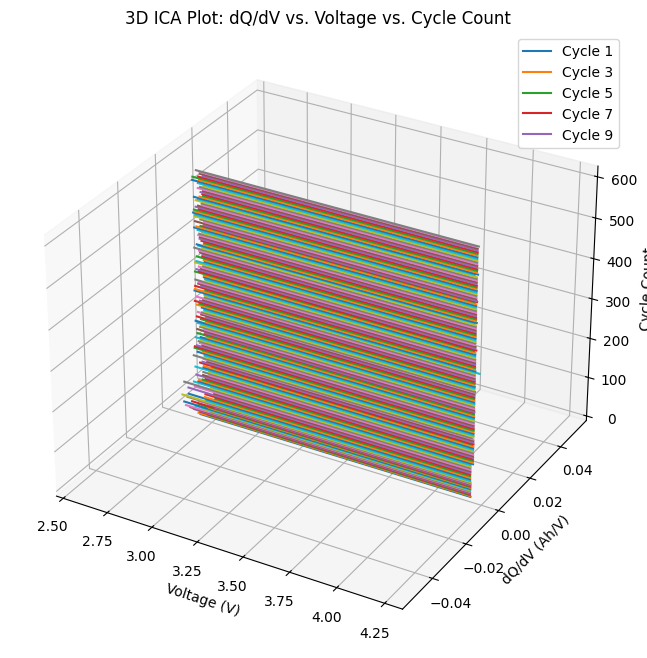

In [17]:
# Compute dQ/dV for each discharge cycle
ica_data = []
cycle_nums = []
for voltage, capacity, cycle_num in discharge_data:
    sorted_idx = np.argsort(voltage)
    voltage = voltage[sorted_idx]
    capacity = capacity[sorted_idx]
    dV = np.diff(voltage)
    dQ = np.diff(capacity)
    dQ_dV = np.where(dV != 0, dQ / dV, np.nan)
    V_mid = (voltage[:-1] + voltage[1:]) / 2
    ica_data.append((V_mid, dQ_dV))
    cycle_nums.append(cycle_num)

if ica_data:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    for i, (V_mid, dQ_dV) in enumerate(ica_data):
        valid_idx = ~np.isnan(dQ_dV)
        ax.plot(V_mid[valid_idx], dQ_dV[valid_idx], zs=cycle_nums[i], zdir='z', label=f'Cycle {cycle_nums[i]}' if i < 5 else None)
    ax.set_xlabel('Voltage (V)')
    ax.set_ylabel('dQ/dV (Ah/V)')
    ax.set_zlabel('Cycle Count')
    ax.set_title('3D ICA Plot: dQ/dV vs. Voltage vs. Cycle Count')
    plt.legend()
    plt.savefig('ica_3d_plot.png')
    plt.show()
else:
    print("No discharge data found for ICA plotting.")


Matched impedance cycle 40 with discharge cycle 41 for ML
Matched impedance cycle 42 with discharge cycle 41 for ML
Matched impedance cycle 44 with discharge cycle 45 for ML
Matched impedance cycle 46 with discharge cycle 45 for ML
Matched impedance cycle 48 with discharge cycle 49 for ML
Matched impedance cycle 50 with discharge cycle 49 for ML
Matched impedance cycle 52 with discharge cycle 53 for ML
Matched impedance cycle 54 with discharge cycle 53 for ML
Matched impedance cycle 56 with discharge cycle 57 for ML
Matched impedance cycle 58 with discharge cycle 57 for ML
Matched impedance cycle 60 with discharge cycle 61 for ML
Matched impedance cycle 62 with discharge cycle 61 for ML
Matched impedance cycle 64 with discharge cycle 65 for ML
Matched impedance cycle 66 with discharge cycle 65 for ML
Matched impedance cycle 68 with discharge cycle 69 for ML
Matched impedance cycle 70 with discharge cycle 69 for ML
Matched impedance cycle 72 with discharge cycle 73 for ML
Matched impeda

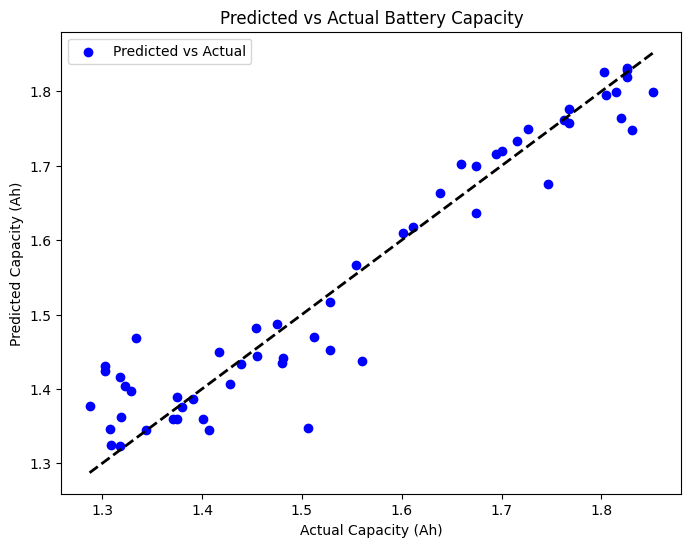

In [18]:
# Task c: Machine Learning Model to Predict Capacity from EIS Signature (using Re, Rct)
X = []
y = []
cycle_to_capacity = {}

# Collect discharge data
discharge_subset = metadata_b0005[metadata_b0005['type'] == 'discharge']
for idx, row in discharge_subset.iterrows():
    cycle_num = int(row.get('test_id', idx))
    capacity = row['Capacity']
    if pd.isna(capacity):
        continue
    try:
        capacity = float(capacity)
    except (ValueError, TypeError):
        print(f"Invalid Capacity for cycle {cycle_num}: {capacity}")
        continue
    cycle_to_capacity[cycle_num] = capacity

# Collect impedance data and match with nearest discharge cycle
impedance_subset = metadata_b0005[metadata_b0005['type'] == 'impedance']
discharge_cycle_nums = sorted(cycle_to_capacity.keys())

for idx, row in impedance_subset.iterrows():
    if pd.isna(row['Re']) or pd.isna(row['Rct']):
        continue
    cycle_num = int(row.get('test_id', idx))
    try:
        re_z = float(row['Re'])
        rct = float(row['Rct'])
    except (ValueError, TypeError):
        print(f"Invalid Re or Rct for cycle {cycle_num}: Re={row['Re']}, Rct={row['Rct']}")
        continue
    nearest_discharge_cycle = min(discharge_cycle_nums, key=lambda x: abs(x - cycle_num))
    if abs(nearest_discharge_cycle - cycle_num) <= 5:
        features = [re_z, rct]
        X.append(features)
        y.append(cycle_to_capacity[nearest_discharge_cycle])
        print(f"Matched impedance cycle {cycle_num} with discharge cycle {nearest_discharge_cycle} for ML")

X = np.array(X)
y = np.array(y)

if len(X) == 0 or len(y) == 0:
    print("No valid data for training. Check EIS and discharge cycle data availability.")
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Mean Squared Error: {mse:.4f}')
    print(f'R^2 Score: {r2:.4f}')
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel('Actual Capacity (Ah)')
    plt.ylabel('Predicted Capacity (Ah)')
    plt.title('Predicted vs Actual Battery Capacity')
    plt.legend()
    plt.savefig('capacity_prediction_plot.png')
    plt.show()

In [19]:
# Output results
print("Plots saved as 'eis_3d_plot.png', 'ica_3d_plot.png', and 'capacity_prediction_plot.png'")
print("Jupyter Notebook can be downloaded from: [http://localhost:8888/notebooks/Untitled57.ipynb, e.g., GitHub or Colab]")


Plots saved as 'eis_3d_plot.png', 'ica_3d_plot.png', and 'capacity_prediction_plot.png'
Jupyter Notebook can be downloaded from: [http://localhost:8888/notebooks/Untitled57.ipynb, e.g., GitHub or Colab]
